# PPO training example on ImprovedB747Env

Этот ноутбук демонстрирует обучение PPO-агента из `tensoraerospace/agent/ppo/model.py` на среде `ImprovedB747Env` из `tensoraerospace/envs/b747.py`.

Особенности:
- Непрерывные действия с гауссовской политикой
- Clipped surrogate objective для стабильных обновлений
- tqdm прогресс-бар и логирование в TensorBoard (losses, policy stats, reward)
- Чекпоинтинг с опциональным сохранением градиентов для продолжения шага


In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent.ppo.model import PPO

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(1)
_ = torch.manual_seed(1)


Using device: mps


In [2]:
# Build environment
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

# Reference theta (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05,
        amplitude=np.deg2rad(1.0),
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Env
env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

obs, info = env.reset()
print("Obs shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)


Obs shape: (4,)
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(-1.0, 1.0, (4,), float32)


In [3]:
# Create PPO agent (tuned hyperparams)
# General tips for ImprovedB747Env:
# - Higher gamma (0.99) improves tracking stability
# - Larger rollout_len (2048) collects more diverse trajectories
# - Moderate clip_param (0.2) balances exploration and stability
# - Lower entropy_coef reduces randomness once converged

agent = PPO(
    env=env,
    gamma=0.99,
    max_episodes=200,
    rollout_len=4096,
    clip_pram=0.15,
    num_epochs=20,
    batch_size=128,
    entropy_coef=0.005,
    actor_lr=2e-4,
    critic_lr=8e-4,
    gae_lambda=0.95,
    max_grad_norm=0.5,
    seed=336699,
)

print("Actor parameters:", sum(p.numel() for p in agent.actor.parameters()))
print("Critic parameters:", sum(p.numel() for p in agent.critic.parameters()))


Actor parameters: 292
Critic parameters: 385


In [4]:
# Quick run (short) — optional
# Train the agent for a few episodes
agent.train()


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [06:25<00:00,  1.93s/it]


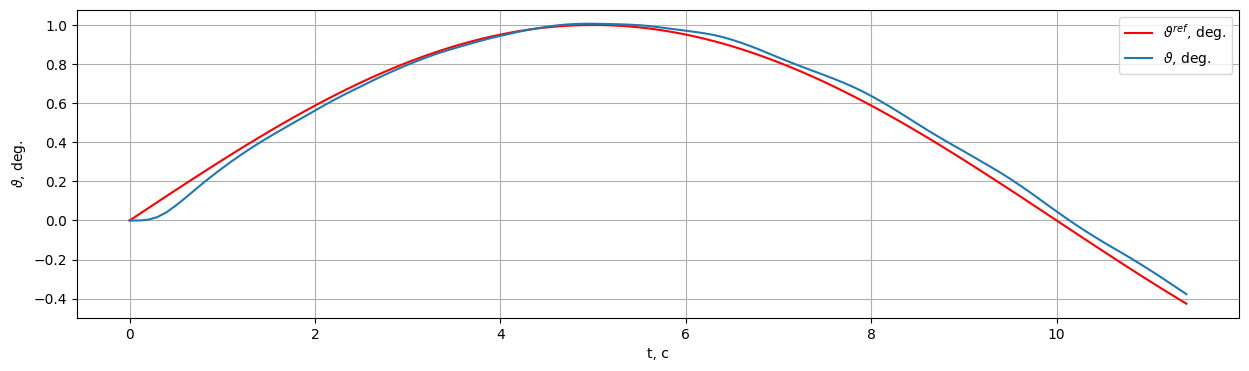

In [5]:
# Plot theta (pitch angle) tracking
env.unwrapped.model.plot_transient_process('theta', tps, reference_signals[0], to_deg=True, figsize=(15,4))


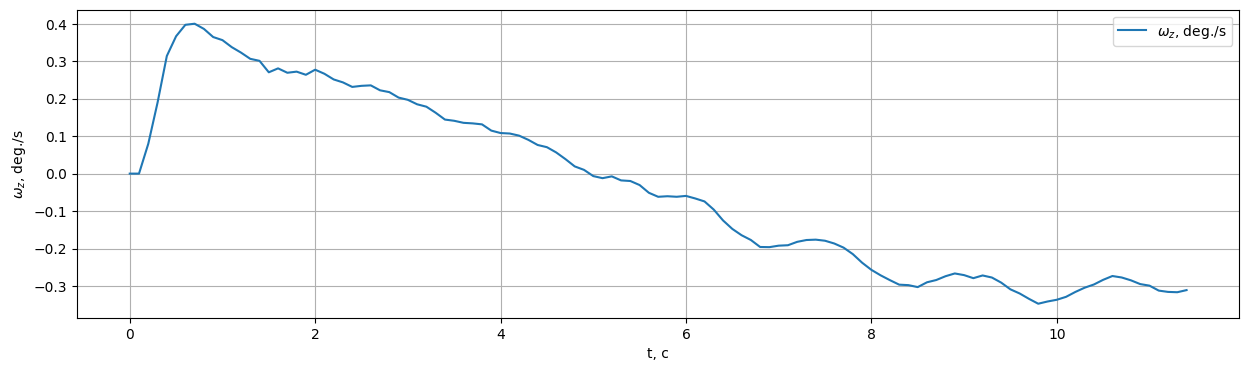

In [6]:
# Plot pitch rate (q)
env.unwrapped.model.plot_state(state_name='q', time=tps, to_deg=True, figsize=(15,4))


/Users/asmazaev/TensorAeroSpace-Origin/tensoraerospace/aerospacemodel/base.py:383: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


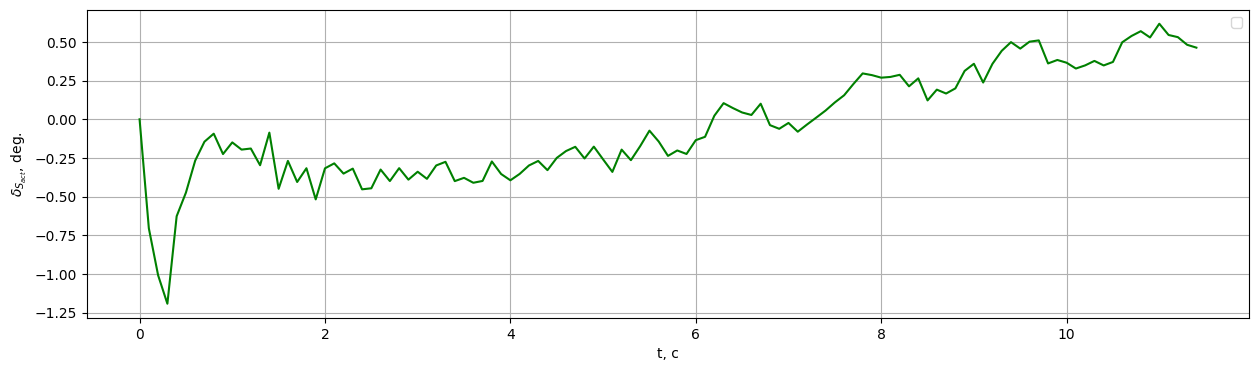

In [7]:
# Plot elevator control
env.unwrapped.model.plot_control(control_name='ele', time=tps, to_deg=True, figsize=(15,4))


In [ ]:
# Save checkpoint
checkpoint_path = os.path.join("runs", "ppo_b747_improved", "ppo_checkpoint.pt")
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

torch.save({
    'actor_state_dict': agent.actor.state_dict(),
    'critic_state_dict': agent.critic.state_dict(),
    'actor_optimizer_state_dict': agent.a_opt.state_dict(),
    'critic_optimizer_state_dict': agent.c_opt.state_dict(),
    'gamma': agent.gamma,
    'clip_param': agent.clip_pram,
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")


In [ ]:
# Full run with more episodes (optional)
max_episodes = 100

# Optionally resume from checkpoint
ckpt_path = os.path.join("runs", "ppo_b747_improved", "ppo_checkpoint.pt")
if os.path.isfile(ckpt_path):
    try:
        checkpoint = torch.load(ckpt_path)
        agent.actor.load_state_dict(checkpoint['actor_state_dict'])
        agent.critic.load_state_dict(checkpoint['critic_state_dict'])
        agent.a_opt.load_state_dict(checkpoint['actor_optimizer_state_dict'])
        agent.c_opt.load_state_dict(checkpoint['critic_optimizer_state_dict'])
        print("Resumed from:", ckpt_path)
    except Exception as e:
        print("Resume failed:", e)

# Ensure logdir
log_root = os.path.join("runs", "ppo_b747_improved")
os.makedirs(log_root, exist_ok=True)

# Update max_episodes for longer training
agent.max_episodes = max_episodes

try:
    agent.train()
finally:
    # Save checkpoint
    ckpt_out = os.path.join(log_root, "ppo_checkpoint_final.pt")
    torch.save({
        'actor_state_dict': agent.actor.state_dict(),
        'critic_state_dict': agent.critic.state_dict(),
        'actor_optimizer_state_dict': agent.a_opt.state_dict(),
        'critic_optimizer_state_dict': agent.c_opt.state_dict(),
        'gamma': agent.gamma,
        'clip_param': agent.clip_pram,
    }, ckpt_out)
    print("Final checkpoint saved to:", ckpt_out)
    agent.writer.close()

print("Training finished.")


## TensorBoard

В отдельной ячейке можно запустить отображение логов TensorBoard:

```python
%load_ext tensorboard
%tensorboard --logdir runs
```
